# Who Gains When Gas Prices Surge?
## A Welfare Analysis of Norway's Gas Economy Under the Ukraine War Supply Shock

**EBA3650 — Quantitative Economics**
BI Norwegian Business School | Spring 2026 | Group of 4

### Research Question

The 2022 Russian invasion of Ukraine triggered one of the largest energy supply shocks in recent history. As Russian pipeline gas to Europe was curtailed — from roughly 155 bcm/year to under 30 bcm — European gas prices surged to unprecedented levels, with TTF spot prices exceeding EUR 300/MWh in August 2022.

Norway — as Europe's now-largest pipeline gas supplier — found itself at the centre of this shift.

This project asks: **Does Norway benefit from the war-induced gas price surge, and if so, who within Norway captures the gains?**

We decompose the welfare effects across three agents:
1. **Gas-producing firms** — producer surplus gain
2. **Norwegian consumers** — welfare loss from higher energy prices
3. **The Norwegian state** — government revenue gain via the 78% petroleum tax

We aggregate these into a net welfare measure and test robustness through sensitivity analysis across key structural parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

### Custom Numerical Solver

We implement the secant method from Session 3 as our primary equation solver.

In [ ]:
# Secant method for equation solving (Session 3)
def our_secant_solver(funcname, x1, x2, arglist):
    y1 = funcname(x1, arglist)
    for _ in range(200):
        y2 = funcname(x2, arglist)
        if abs(y1) < 1e-10:
            return x1
        x_new = x1 - y1 * (x2 - x1) / (y2 - y1)
        x1 = x2
        y1 = y2
        x2 = x_new
    return x2

# Quick test on a known equation: x^2 - 4 = 0 => x = 2
def test_eq(x, args):
    return x**2 - 4

print(f"Secant solver:  x = {our_secant_solver(test_eq, 1, 3, None):.8f}")
print("Solver verified: x^2 = 4 => x = 2.0")

## 2. Background: Norway as Europe's Gas Supplier

**Pre-war European gas market:**
- Total European gas consumption: ~4,000 TWh/year (~400 bcm)
- Russia supplied roughly 40% of European gas via pipelines (Nord Stream, Yamal, Brotherhood)
- Norway supplied approximately 25% through pipelines (Langeled, Europipe) and some LNG
- Pre-war TTF gas prices: ~20 EUR/MWh (2019–2021 average)

**The shock:**
- Following the February 2022 invasion, Russian pipeline gas was progressively curtailed
- Nord Stream flows fell to zero by September 2022
- European gas prices surged: TTF peaked above 300 EUR/MWh in August 2022
- Norway maximised pipeline exports, becoming Europe's single largest gas supplier

**Three welfare channels for Norway:**
1. **Producer surplus gain**: Norwegian gas firms sell at much higher prices. Even with limited capacity to expand output, revenue per unit surges.
2. **Consumer welfare loss**: Higher gas prices feed through to Norwegian electricity prices via Nordic-European market interconnectors (NordLink, North Sea Link). Norwegian households face substantially higher energy bills.
3. **Government revenue gain**: The Norwegian petroleum tax system captures ~78% of upstream petroleum profits. The windfall from higher gas prices flows primarily to the state, funding the Government Pension Fund Global.

## 3. Partial Equilibrium European Gas Market Model

We model the European gas market using constant-elasticity supply and demand curves — the standard framework from Sessions 2–3. We calibrate to a pre-war baseline, simulate the Russian supply shock, and solve for the new equilibrium.

**Supply:** $Q_s(P) = A_s \cdot P^{\epsilon_s}$

**Demand:** $Q_d(P) = A_d \cdot P^{\epsilon_d}$

where $\epsilon_d < 0$ (downward-sloping demand) and $\epsilon_s > 0$ (upward-sloping supply).

**Equilibrium** is found by solving $Q_d(P) = Q_s(P)$ for $P$.

In [3]:
# Constant-elasticity supply and demand functions
def demand(price, level, el):
    return level * price**el

def supply(price, level, el):
    return level * price**el

def inverse_supply(q, level, el):
    return (q / level)**(1.0 / el)

### 3.1 Calibration

We calibrate the scale parameters $A_d$ and $A_s$ so that both curves pass through the pre-war equilibrium: $P_0 = 20$ EUR/MWh, $Q_0 = 4000$ TWh/year.

In [4]:
# Pre-war baseline
P0 = 20.0        # EUR/MWh (pre-war TTF average)
Q0 = 4000.0      # TWh/year (European gas consumption)

# Baseline elasticities
eps_d = -0.3     # short-run gas demand elasticity
eps_s = 0.35     # short-run gas supply elasticity

# Calibrate scale parameters: Q0 = A * P0^eps => A = Q0 / P0^eps
A_d = Q0 / P0**eps_d
A_s = Q0 / P0**eps_s

# Verify calibration
print(f"Demand at P0={P0}: {demand(P0, A_d, eps_d):.1f} TWh/yr (should be {Q0:.1f})")
print(f"Supply at P0={P0}: {supply(P0, A_s, eps_s):.1f} TWh/yr (should be {Q0:.1f})")
print(f"Scale parameters: A_d = {A_d:.2f}, A_s = {A_s:.2f}")

Demand at P0=20.0: 4000.0 TWh/yr (should be 4000.0)
Supply at P0=20.0: 4000.0 TWh/yr (should be 4000.0)
Scale parameters: A_d = 9825.82, A_s = 1401.84


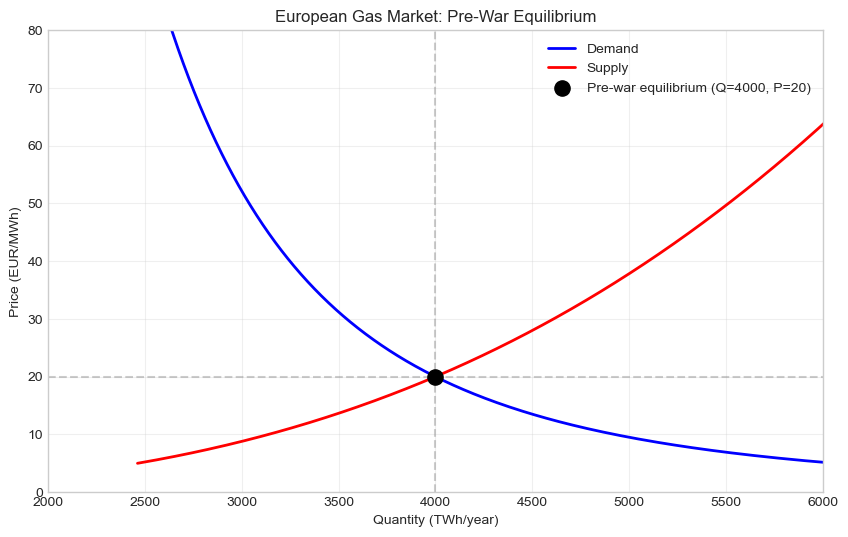

In [5]:
# Plot pre-war equilibrium
prices = np.linspace(5, 80, 500)
qd = demand(prices, A_d, eps_d)
qs = supply(prices, A_s, eps_s)

plt.figure(figsize=(10, 6))
plt.plot(qd, prices, '-b', linewidth=2, label='Demand')
plt.plot(qs, prices, '-r', linewidth=2, label='Supply')
plt.scatter(Q0, P0, s=120, color='black', zorder=5, label=f'Pre-war equilibrium (Q={Q0:.0f}, P={P0:.0f})')
plt.axhline(y=P0, linestyle='--', color='gray', alpha=0.4)
plt.axvline(x=Q0, linestyle='--', color='gray', alpha=0.4)
plt.xlabel('Quantity (TWh/year)')
plt.ylabel('Price (EUR/MWh)')
plt.title('European Gas Market: Pre-War Equilibrium')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(2000, 6000)
plt.ylim(0, 80)
plt.show()

### 3.2 Supply Shock Simulation

The Russian invasion removed a large fraction of European gas supply. Russia's share of European gas was approximately 40%. We model this as a leftward shift of the supply curve:

$$Q_s^{\text{post}}(P) = (1 - \delta) \cdot A_s \cdot P^{\epsilon_s}$$

where $\delta$ is the fraction of supply removed. At $\delta = 0.40$, we remove 40% of total supply — roughly matching Russia's pre-war share.

**Key modeling point:** The shock removes *Russian* supply. Norwegian supply is *unchanged* — Norway still has the same supply curve $Q_{NO}(P) = A_{NO} \cdot P^{\epsilon_s}$. But the market-clearing price rises, so Norway sells at a higher price and moves up along its supply curve.

In [ ]:
# Supply shock parameters
delta = 0.40            # fraction of supply removed (Russia's share)
norway_share = 0.25     # Norway's share of total pre-war supply

# Norwegian supply scale parameter (unchanged by the shock)
A_NO = norway_share * A_s

# Excess demand function for our custom solver
def excess_demand(price, params):
    A_d, eps_d, A_s, eps_s, delta = params
    return demand(price, A_d, eps_d) - supply(price, (1 - delta) * A_s, eps_s)

# Solve with secant method (Session 3 technique)
P1 = our_secant_solver(excess_demand, 10.0, 80.0, [A_d, eps_d, A_s, eps_s, delta])
Q1 = demand(P1, A_d, eps_d)

print(f"=== New Equilibrium After Supply Shock (delta={delta:.0%}) ===")
print(f"P1 = {P1:.2f} EUR/MWh, Q1 = {Q1:.1f} TWh/yr")
print(f"")
print(f"Price increase: {P1/P0:.1f}x  ({(P1/P0 - 1)*100:.0f}%)")
print(f"Quantity decrease: {(1 - Q1/Q0)*100:.1f}%")

In [ ]:
# Plot: pre-war vs post-shock equilibrium
prices = np.linspace(5, 120, 500)
qd = demand(prices, A_d, eps_d)
qs_pre = supply(prices, A_s, eps_s)
qs_post = supply(prices, (1 - delta) * A_s, eps_s)

plt.figure(figsize=(10, 6))
plt.plot(qd, prices, '-b', linewidth=2, label='Demand')
plt.plot(qs_pre, prices, '-r', linewidth=2, label='Supply (pre-war)')
plt.plot(qs_post, prices, '--r', linewidth=2, label=f'Supply (post-shock, δ={delta:.0%})')
plt.scatter(Q0, P0, s=120, color='black', zorder=5, label=f'Pre-war: P={P0:.0f}, Q={Q0:.0f}')
plt.scatter(Q1, P1, s=120, color='red', zorder=5,
            label=f'Post-shock: P={P1:.1f}, Q={Q1:.0f}')
plt.annotate('', xy=(Q1, P1), xytext=(Q0, P0),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2))
plt.axhline(y=P0, linestyle=':', color='gray', alpha=0.3)
plt.axhline(y=P1, linestyle=':', color='gray', alpha=0.3)
plt.xlabel('Quantity (TWh/year)')
plt.ylabel('Price (EUR/MWh)')
plt.title('European Gas Market: Supply Shock from Russian Gas Curtailment')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(1500, 6000)
plt.ylim(0, 120)
plt.show()

### 3.3 Norwegian Producer Surplus

Norwegian gas producers are price-takers in the European market. Their supply curve is $Q_{NO}(P) = A_{NO} \cdot P^{\epsilon_s}$, with $A_{NO}$ unchanged by the shock.

**Producer surplus** is the area between the equilibrium price and the supply curve:

$$PS = P \cdot Q_{NO} - \int_0^{Q_{NO}} S^{-1}(q) \, dq$$

For constant-elasticity supply $Q = A \cdot P^\epsilon$, the inverse is $P = (Q/A)^{1/\epsilon}$, and the integral has a closed form:

$$\int_0^{Q} (q/A)^{1/\epsilon} \, dq = \frac{A^{-1/\epsilon} \cdot Q^{1 + 1/\epsilon}}{1 + 1/\epsilon}$$

In [ ]:
# Analytical producer surplus formula for constant-elasticity supply
def ps_analytical(eq_price, A, eps):
    Q = supply(eq_price, A, eps)
    cost_integral = A**(-1/eps) * Q**(1 + 1/eps) / (1 + 1/eps)
    revenue = eq_price * Q
    return revenue - cost_integral

# Numerical verification: "integration by force" (Session 7 technique)
def ps_numerical(eq_price, A, eps, n_grid=50000):
    Q = supply(eq_price, A, eps)
    grid = np.linspace(1e-6, Q, n_grid)
    mc = inverse_supply(grid, A, eps)
    cost = Q * np.mean(mc)
    revenue = eq_price * Q
    return revenue - cost

# Pre-war Norwegian PS
PS_pre_analytical = ps_analytical(P0, A_NO, eps_s)
PS_pre_numerical = ps_numerical(P0, A_NO, eps_s)

# Post-shock Norwegian PS (same supply curve A_NO, higher price P1)
PS_post_analytical = ps_analytical(P1, A_NO, eps_s)
PS_post_numerical = ps_numerical(P1, A_NO, eps_s)

# Convert units: TWh * EUR/MWh = 10^6 EUR => divide by 10^3 for billion EUR
scale = 1e3  # TWh * EUR/MWh / 10^3 = billion EUR

delta_PS = PS_post_analytical - PS_pre_analytical

print(f"=== Norwegian Producer Surplus ===")
print(f"Pre-war  (analytical): {PS_pre_analytical/scale:.2f} bn EUR")
print(f"Pre-war  (numerical):  {PS_pre_numerical/scale:.2f} bn EUR")
print(f"Post-shock (analytical): {PS_post_analytical/scale:.2f} bn EUR")
print(f"Post-shock (numerical):  {PS_post_numerical/scale:.2f} bn EUR")
print(f"")
print(f"Change in PS: +{delta_PS/scale:.2f} bn EUR")
print(f"Analytical vs numerical error: {abs(PS_pre_analytical - PS_pre_numerical)/scale:.6f} bn EUR")

In [ ]:
# Visualise Norwegian producer surplus: pre-war vs post-shock
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pre-war PS
Q_NO_pre = supply(P0, A_NO, eps_s)
q_range_pre = np.linspace(1e-3, Q_NO_pre, 500)
mc_pre = inverse_supply(q_range_pre, A_NO, eps_s)

ax1.fill_between(q_range_pre, mc_pre, P0, alpha=0.3, color='green', label='Producer surplus')
ax1.plot(q_range_pre, mc_pre, '-r', linewidth=2, label='Norwegian supply (MC)')
ax1.axhline(y=P0, color='blue', linestyle='--', linewidth=1.5, label=f'Market price P₀={P0:.0f}')
ax1.scatter(Q_NO_pre, P0, s=80, color='black', zorder=5)
ax1.set_xlabel('Norwegian quantity (TWh/year)')
ax1.set_ylabel('Price (EUR/MWh)')
ax1.set_title(f'Pre-War PS = {PS_pre_analytical/scale:.1f} bn EUR')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, P1 * 1.1)

# Post-shock PS
Q_NO_post = supply(P1, A_NO, eps_s)
q_range_post = np.linspace(1e-3, Q_NO_post, 500)
mc_post = inverse_supply(q_range_post, A_NO, eps_s)

ax2.fill_between(q_range_post, mc_post, P1, alpha=0.3, color='green', label='Producer surplus')
ax2.plot(q_range_post, mc_post, '-r', linewidth=2, label='Norwegian supply (MC)')
ax2.axhline(y=P1, color='blue', linestyle='--', linewidth=1.5, label=f'Market price P₁={P1:.1f}')
ax2.scatter(Q_NO_post, P1, s=80, color='black', zorder=5)
ax2.set_xlabel('Norwegian quantity (TWh/year)')
ax2.set_ylabel('Price (EUR/MWh)')
ax2.set_title(f'Post-Shock PS = {PS_post_analytical/scale:.1f} bn EUR')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, P1 * 1.1)

plt.suptitle('Norwegian Gas Producer Surplus: Before and After the Shock', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Norwegian output pre-war:   {Q_NO_pre:.0f} TWh/yr")
print(f"Norwegian output post-shock: {Q_NO_post:.0f} TWh/yr (+{(Q_NO_post/Q_NO_pre - 1)*100:.1f}%)")

**Interpretation:** Norwegian gas producers gain substantially from the price surge. Although they can only modestly expand output (constrained by pipeline capacity and field production), the much higher market price means that revenue per unit increases dramatically.

*Note: The change in Norwegian output is moderate because supply elasticity is low (εₛ = 0.35). Most of the PS gain comes from the higher price on existing production, not from volume expansion.*

## 4. Consumer Welfare: Compensating Variation

Norwegian households face higher energy prices as European gas prices feed through to Nordic electricity markets via interconnectors (NordLink to Germany, North Sea Link to UK). We measure the welfare loss using **compensating variation** (CV) from consumer theory (Sessions 3–4).

### Quasi-linear utility

We use a quasi-linear utility function:

$$u(g, y) = y + \frac{B}{1 - 1/\eta} \cdot g^{1 - 1/\eta}$$

where $g$ is energy consumption, $y$ is all other goods (numeraire), $B$ is a preference parameter, and $\eta$ is the price elasticity of energy demand.

The first-order condition gives demand: $g(p) = (B/p)^\eta$

**Key property of quasi-linear utility:** The compensating variation equals the change in consumer surplus — the area under the demand curve between the old and new prices:

$$CV = \int_{p_0}^{p_1} g(p) \, dp = V(p_0, I) - V(p_1, I)$$

In [10]:
# Quasi-linear utility functions (Session 5 pattern)
def utility_ql(g, y, B, eta):
    return y + B / (1 - 1/eta) * g**(1 - 1/eta)

def demand_energy(price, B, eta):
    return (B / price)**eta

def indirect_utility_ql(income, price, B, eta):
    g = demand_energy(price, B, eta)
    y = income - price * g
    return utility_ql(g, y, B, eta)

In [ ]:
# Calibrate consumer parameters
eta_c = 0.3              # household energy demand elasticity (very inelastic short-run)
I_household = 50000.0    # representative household income (EUR/year)
n_households = 2.4e6     # ~2.4 million Norwegian households

# Gas-to-electricity price passthrough coefficient
passthrough = 0.5

# Domestic energy prices
p_energy_pre = P0 * passthrough
p_energy_post = P1 * passthrough

# Calibrate B so that pre-war energy expenditure is ~2000 EUR/yr per household
energy_spend_target = 2000.0  # EUR/year
g_target = energy_spend_target / p_energy_pre
B_consumer = p_energy_pre * g_target**(1.0 / eta_c)

# Verify calibration
g_check = demand_energy(p_energy_pre, B_consumer, eta_c)
spend_check = p_energy_pre * g_check

print(f"=== Consumer Calibration ===")
print(f"Pre-war energy price:  {p_energy_pre:.1f} EUR/MWh")
print(f"Post-shock energy price: {p_energy_post:.1f} EUR/MWh  (+{(p_energy_post/p_energy_pre-1)*100:.0f}%)")
print(f"Pre-war energy demand: {g_check:.1f} MWh/yr per household")
print(f"Pre-war energy spend:  {spend_check:.0f} EUR/yr (target: {energy_spend_target:.0f})")
print(f"B_consumer = {B_consumer:.4f}")

g_post = demand_energy(p_energy_post, B_consumer, eta_c)
y_post = I_household - p_energy_post * g_post
print(f"Post-shock energy spend: {p_energy_post * g_post:.0f} EUR/yr")
print(f"Post-shock numeraire:    {y_post:.0f} EUR/yr (must be > 0: {'OK' if y_post > 0 else 'WARNING'})")

In [12]:
# Compensating Variation: two methods

# Method 1: Utility difference (exact for quasi-linear)
V_pre = indirect_utility_ql(I_household, p_energy_pre, B_consumer, eta_c)
V_post = indirect_utility_ql(I_household, p_energy_post, B_consumer, eta_c)
CV_household = V_pre - V_post  # positive = welfare loss

# Method 2: Numerical integration of demand curve ("integration by force", Session 7)
p_grid = np.linspace(p_energy_pre, p_energy_post, 50000)
g_grid = demand_energy(p_grid, B_consumer, eta_c)
CV_integral = (p_energy_post - p_energy_pre) * np.mean(g_grid)

# Scale to all Norwegian households (convert to billion EUR)
CV_total = CV_household * n_households

print(f"=== Compensating Variation ===")
print(f"CV per household (utility method):    {CV_household:.2f} EUR/yr")
print(f"CV per household (integral method):   {CV_integral:.2f} EUR/yr")
print(f"Methods agree to: {abs(CV_household - CV_integral):.4f} EUR")
print(f"")
print(f"Total consumer welfare loss (Norway): {CV_total/1e9:.3f} bn EUR/yr")
print(f"  = {CV_total/n_households:.0f} EUR per household")

=== Compensating Variation ===
CV per household (utility method):    2095.60 EUR/yr
CV per household (integral method):   2095.60 EUR/yr
Methods agree to: 0.0008 EUR

Total consumer welfare loss (Norway): 5.029 bn EUR/yr
  = 2096 EUR per household


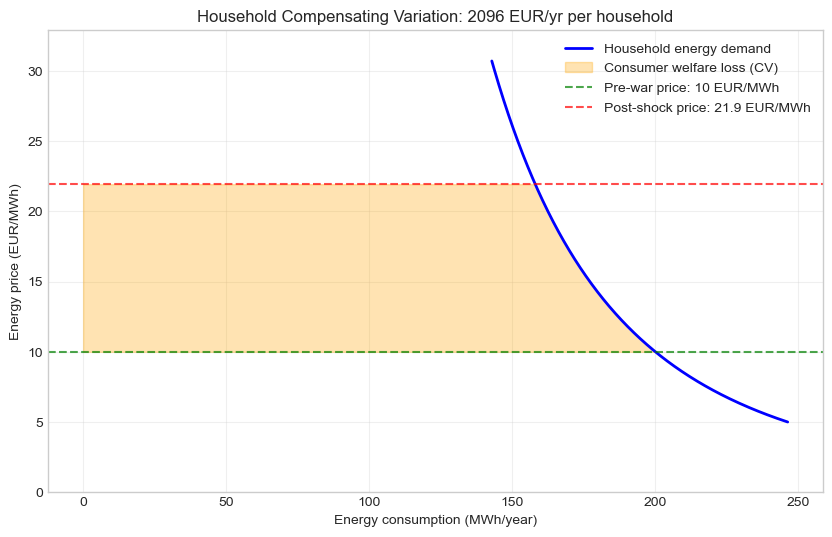

In [13]:
# Plot: Consumer welfare loss visualisation
p_wide = np.linspace(p_energy_pre * 0.5, p_energy_post * 1.4, 500)
g_wide = demand_energy(p_wide, B_consumer, eta_c)

p_fill = np.linspace(p_energy_pre, p_energy_post, 500)
g_fill = demand_energy(p_fill, B_consumer, eta_c)

plt.figure(figsize=(10, 6))
plt.plot(g_wide, p_wide, '-b', linewidth=2, label='Household energy demand')
plt.fill_betweenx(p_fill, demand_energy(p_fill, B_consumer, eta_c), 0,
                  alpha=0.3, color='orange', label=f'Consumer welfare loss (CV)')
plt.axhline(y=p_energy_pre, linestyle='--', color='green', alpha=0.7, label=f'Pre-war price: {p_energy_pre:.0f} EUR/MWh')
plt.axhline(y=p_energy_post, linestyle='--', color='red', alpha=0.7, label=f'Post-shock price: {p_energy_post:.1f} EUR/MWh')
plt.xlabel('Energy consumption (MWh/year)')
plt.ylabel('Energy price (EUR/MWh)')
plt.title(f'Household Compensating Variation: {CV_household:.0f} EUR/yr per household')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(0, p_energy_post * 1.5)
plt.show()

**Interpretation:** The compensating variation shows the monetary welfare loss per household from the energy price increase. Aggregated over 2.4 million Norwegian households, this gives the total consumer welfare loss — significant, but as we will see, much smaller than the producer surplus gain channelled through the government.

Note that the demand elasticity is very low ($\eta = 0.3$): households cannot easily reduce energy consumption in the short run, so they absorb most of the price increase through higher spending.

## 5. Petroleum Tax as a Pigou-Style Tax

Norway's petroleum tax system imposes an effective marginal tax rate of approximately **78%** on upstream petroleum profits (including gas production). This functions as a near-confiscatory tax on economic rents from resource extraction.

We decompose the producer surplus into:
- **Government revenue:** $G = \tau \cdot PS$
- **Firm profit (after tax):** $\Pi = (1 - \tau) \cdot PS$

where $\tau = 0.78$ is the petroleum tax rate.

In [14]:
# Petroleum tax decomposition
tau = 0.78  # effective petroleum tax rate

# Pre-war
G_pre = tau * PS_pre_analytical
profit_pre = (1 - tau) * PS_pre_analytical

# Post-shock
G_post = tau * PS_post_analytical
profit_post = (1 - tau) * PS_post_analytical

# Changes
delta_G = G_post - G_pre
delta_profit = profit_post - profit_pre

print(f"=== Petroleum Tax Decomposition (tau = {tau:.0%}) ===")
print(f"")
print(f"{'':>30s} {'Pre-war':>12s} {'Post-shock':>12s} {'Change':>12s}")
print(f"{'─'*66}")
print(f"{'Gross producer surplus':>30s} {PS_pre_analytical/scale:>12.2f} {PS_post_analytical/scale:>12.2f} {delta_PS/scale:>+12.2f}")
print(f"{'Government revenue (78%)':>30s} {G_pre/scale:>12.2f} {G_post/scale:>12.2f} {delta_G/scale:>+12.2f}")
print(f"{'Firm profit (22%)':>30s} {profit_pre/scale:>12.2f} {profit_post/scale:>12.2f} {delta_profit/scale:>+12.2f}")
print(f"{'Consumer welfare loss':>30s} {'':>12s} {'':>12s} {-CV_total/1e9:>+12.3f}")
print(f"{'─'*66}")
print(f"{'(All values in billion EUR)':>30s}")

=== Petroleum Tax Decomposition (tau = 78%) ===

                                    Pre-war   Post-shock       Change
──────────────────────────────────────────────────────────────────
        Gross producer surplus        14.81        42.80       +27.99
      Government revenue (78%)        11.56        33.39       +21.83
             Firm profit (22%)         3.26         9.42        +6.16
         Consumer welfare loss                                 -5.029
──────────────────────────────────────────────────────────────────
   (All values in billion EUR)


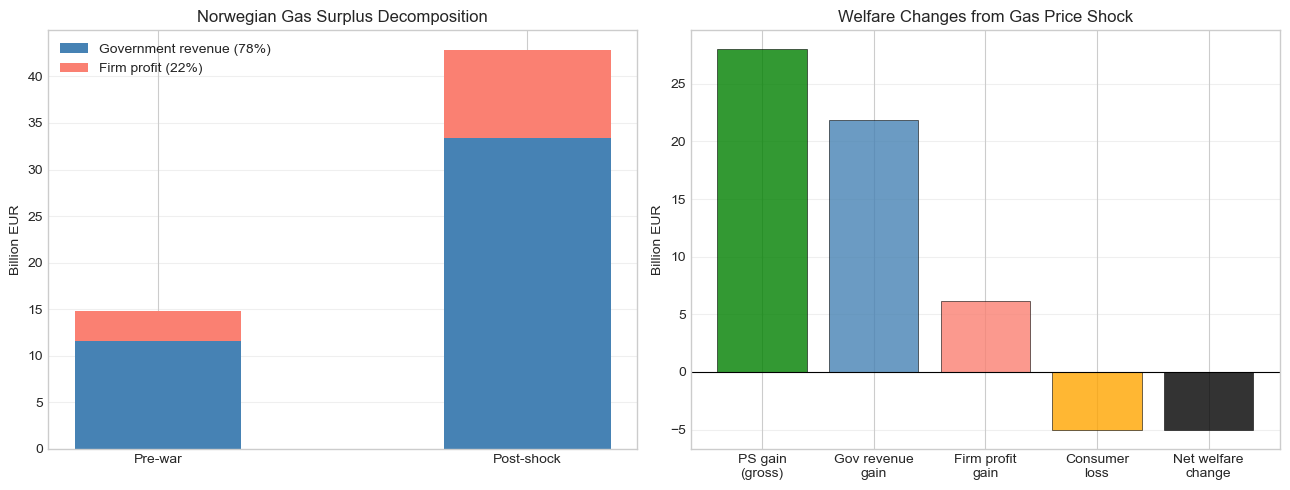

In [15]:
# Stacked bar chart: surplus decomposition
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: absolute values pre vs post
labels = ['Pre-war', 'Post-shock']
gov_vals = [G_pre/scale, G_post/scale]
firm_vals = [profit_pre/scale, profit_post/scale]

x_pos = np.arange(len(labels))
width = 0.45

ax1.bar(x_pos, gov_vals, width, label='Government revenue (78%)', color='steelblue')
ax1.bar(x_pos, firm_vals, width, bottom=gov_vals, label='Firm profit (22%)', color='salmon')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels)
ax1.set_ylabel('Billion EUR')
ax1.set_title('Norwegian Gas Surplus Decomposition')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

# Right panel: changes (waterfall-style)
changes = ['PS gain\n(gross)', 'Gov revenue\ngain', 'Firm profit\ngain', 'Consumer\nloss', 'Net welfare\nchange']
net_W = delta_G + delta_profit - CV_total
values = [delta_PS/scale, delta_G/scale, delta_profit/scale, -CV_total/1e9, net_W/1e9]
colors_bar = ['green', 'steelblue', 'salmon', 'orange', 'black']

ax2.bar(changes, values, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylabel('Billion EUR')
ax2.set_title('Welfare Changes from Gas Price Shock')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 5.1 Who Gains? Distributional Analysis

The research question asks not just *whether* Norway benefits, but **who within Norway captures the gains**. The answer is strikingly uneven:

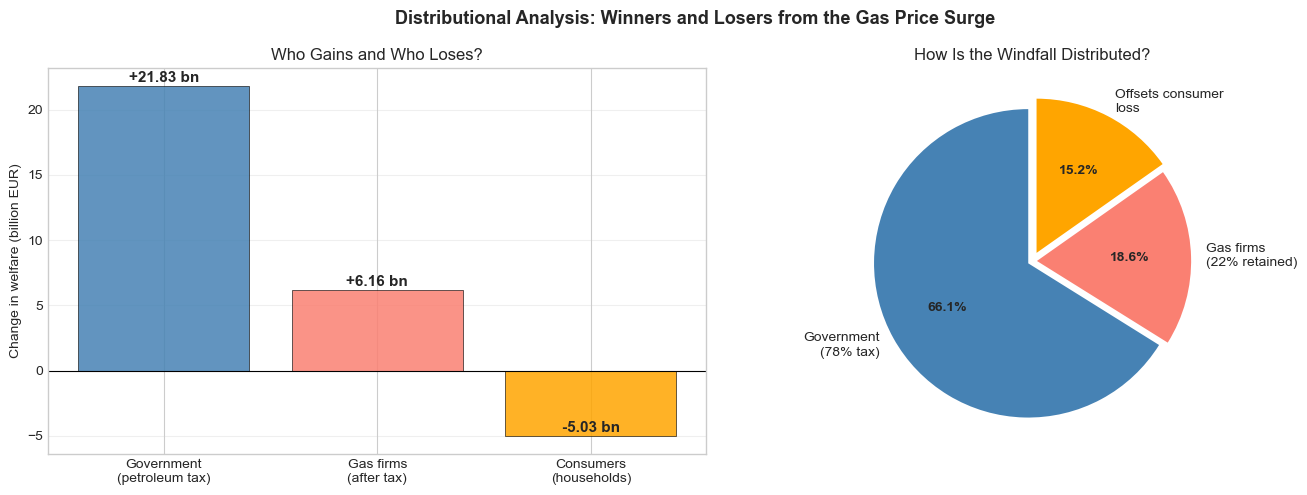

The gross producer surplus windfall is 27.99 bn EUR.

  → Government captures 21.83 bn EUR (78% of windfall)
  → Gas firms retain    6.16 bn EUR (22% of windfall)
  → Consumers lose      5.03 bn EUR

The government is the DOMINANT winner — receiving 78% of the windfall.
Consumer losses are 18.0% of the gross windfall — easily offset.

If the government redistributed just 5.03 bn of its 21.83 bn gain,
every household could be fully compensated (2096 EUR each),
and the state would STILL retain 16.80 bn EUR.


In [16]:
# === WHO GAINS? — Distributional breakdown ===

# Compute gains/losses per agent
agents = ['Government\n(petroleum tax)', 'Gas firms\n(after tax)', 'Consumers\n(households)']
agent_changes = [delta_G/scale, delta_profit/scale, -CV_total/1e9]
agent_colors = ['steelblue', 'salmon', 'orange']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute gains/losses per agent
bars = ax1.bar(agents, agent_changes, color=agent_colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax1.axhline(y=0, color='black', linewidth=0.8)
for bar, val in zip(bars, agent_changes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:+.2f} bn', ha='center', fontweight='bold', fontsize=11)
ax1.set_ylabel('Change in welfare (billion EUR)')
ax1.set_title('Who Gains and Who Loses?')
ax1.grid(True, alpha=0.3, axis='y')

# Right: pie chart of the WINDFALL (positive gains only)
# How is the gross PS windfall distributed?
pie_labels = [f'Government\n({tau:.0%} tax)', f'Gas firms\n({1-tau:.0%} retained)', f'Offsets consumer\nloss']
pie_values = [delta_G/scale, delta_profit/scale, CV_total/1e9]
pie_colors = ['steelblue', 'salmon', 'orange']
explode = (0.03, 0.03, 0.06)

wedges, texts, autotexts = ax2.pie(pie_values, labels=pie_labels, colors=pie_colors,
                                    autopct='%1.1f%%', startangle=90, explode=explode,
                                    textprops={'fontsize': 10})
for t in autotexts:
    t.set_fontweight('bold')
ax2.set_title('How Is the Windfall Distributed?')

plt.suptitle('Distributional Analysis: Winners and Losers from the Gas Price Surge',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the story
print(f"The gross producer surplus windfall is {delta_PS/scale:.2f} bn EUR.")
print(f"")
print(f"  → Government captures {delta_G/scale:.2f} bn EUR ({tau:.0%} of windfall)")
print(f"  → Gas firms retain    {delta_profit/scale:.2f} bn EUR ({1-tau:.0%} of windfall)")
print(f"  → Consumers lose      {CV_total/1e9:.2f} bn EUR")
print(f"")
print(f"The government is the DOMINANT winner — receiving {delta_G/delta_PS*100:.0f}% of the windfall.")
print(f"Consumer losses are {CV_total/1e9/(delta_PS/scale)*100:.1f}% of the gross windfall — easily offset.")
print(f"")
print(f"If the government redistributed just {CV_total/1e9:.2f} bn of its {delta_G/scale:.2f} bn gain,")
print(f"every household could be fully compensated ({CV_total/n_households:.0f} EUR each),")
print(f"and the state would STILL retain {(delta_G/scale - CV_total/1e9):.2f} bn EUR.")

**Key insight:** The Norwegian state is overwhelmingly the biggest winner. The 78% petroleum tax channels most of the windfall to the government. Gas firms also gain, but retain only 22% of the surplus increase. Consumers are the clear losers — but their total loss is small relative to the government's gain.

This means the government has more than enough fiscal space to fully compensate all households and *still* come out far ahead. Whether this actually happens is a political question, not an economic one — but the *potential* for a Pareto improvement exists.

### 5.2 Ramsey Optimal Taxation: Why 78% Is Not Distortionary

A key insight from optimal taxation theory (Session 9) is the distinction between **rent taxes** and **per-unit taxes**:

- A **profits/rent tax** captures a share of surplus *without changing production decisions*. Since the tax is on profits (revenue minus costs), firms still maximise the same objective — the tax rate cancels from the first-order conditions. There is **no deadweight loss**.

- A **per-unit (excise) tax** creates a wedge between the price consumers pay and the price producers receive, causing underproduction and deadweight loss. The Ramsey rule says such taxes should be inversely proportional to elasticity.

Norway's 78% petroleum tax is a *profits tax*. It extracts most of the rent but does not distort the supply curve. This is why such a high rate is economically efficient.

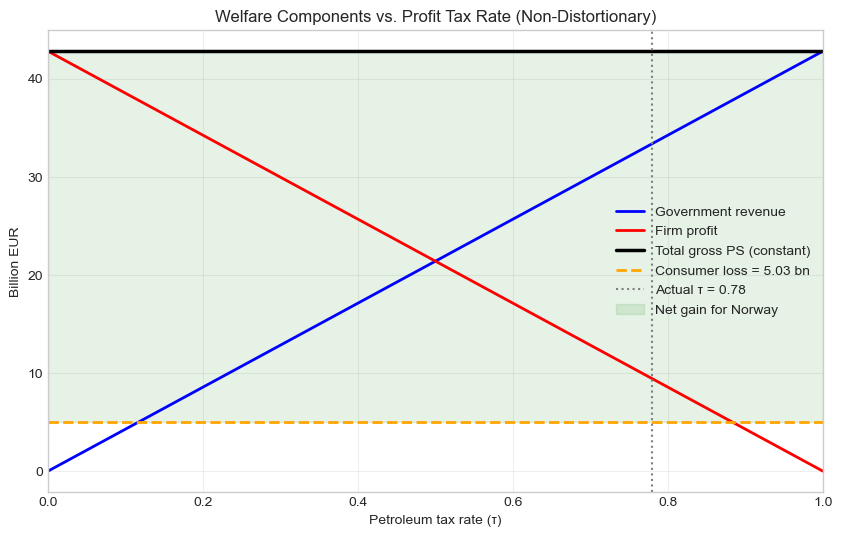

Total gross PS is constant at 42.80 bn EUR regardless of tax rate.
The tax only redistributes between government and firms — no DWL.


In [17]:
# Demonstrate: welfare components are INDEPENDENT of profit tax rate
# (because profit tax doesn't distort production)
tax_rates = np.linspace(0, 1.0, 200)
gov_rev_curve = np.zeros(200)
firm_prof_curve = np.zeros(200)
total_surplus_curve = np.zeros(200)

for i in range(200):
    t = tax_rates[i]
    gov_rev_curve[i] = t * PS_post_analytical / scale
    firm_prof_curve[i] = (1 - t) * PS_post_analytical / scale
    total_surplus_curve[i] = PS_post_analytical / scale  # constant!

plt.figure(figsize=(10, 6))
plt.plot(tax_rates, gov_rev_curve, '-b', linewidth=2, label='Government revenue')
plt.plot(tax_rates, firm_prof_curve, '-r', linewidth=2, label='Firm profit')
plt.plot(tax_rates, total_surplus_curve, '-k', linewidth=2.5, label='Total gross PS (constant)')
plt.axhline(y=CV_total/1e9, color='orange', linestyle='--', linewidth=2, label=f'Consumer loss = {CV_total/1e9:.2f} bn')
plt.axvline(x=0.78, color='gray', linestyle=':', linewidth=1.5, label='Actual τ = 0.78')
plt.fill_between(tax_rates, CV_total/1e9, total_surplus_curve, alpha=0.1, color='green', label='Net gain for Norway')
plt.xlabel('Petroleum tax rate (τ)')
plt.ylabel('Billion EUR')
plt.title('Welfare Components vs. Profit Tax Rate (Non-Distortionary)')
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.show()

print(f"Total gross PS is constant at {PS_post_analytical/scale:.2f} bn EUR regardless of tax rate.")
print(f"The tax only redistributes between government and firms — no DWL.")

### 5.3 Comparison: What If Norway Used a Per-Unit Tax Instead?

To illustrate why the profits tax design matters, we compute the hypothetical deadweight loss if Norway instead taxed gas production with a per-unit (excise) tax. A per-unit tax $t$ shifts the supply curve upward: firms require price $P + t$ to produce the same quantity.

In [ ]:
# Hypothetical per-unit tax analysis (distortionary)
unit_taxes = np.linspace(0, P1 * 0.8, 150)
welfare_unit = np.zeros(150)
dwl_unit = np.zeros(150)
gov_rev_unit = np.zeros(150)

# Reference: welfare without any tax (just the shock)
W_notax = PS_post_analytical / scale - CV_total / 1e9

for i in range(150):
    t = unit_taxes[i]
    def excess_with_unit_tax(price):
        if price <= t + 0.01:
            return 1e10
        return demand(price, A_d, eps_d) - supply(price - t, (1 - delta) * A_s, eps_s)

    try:
        P_tax = opt.bisect(excess_with_unit_tax, t + 0.02, 500)
        Q_tax = demand(P_tax, A_d, eps_d)
        Q_NO_tax = supply(P_tax - t, A_NO, eps_s)

        ps_nor = ps_analytical(P_tax - t, A_NO, eps_s)
        gov_rev_unit[i] = (t * Q_NO_tax) / scale

        welfare_unit[i] = ps_nor / scale + gov_rev_unit[i] - CV_total / 1e9
        dwl_unit[i] = W_notax - welfare_unit[i]
    except:
        welfare_unit[i] = np.nan
        dwl_unit[i] = np.nan
        gov_rev_unit[i] = np.nan

plt.figure(figsize=(10, 6))
plt.plot(unit_taxes, dwl_unit, '-r', linewidth=2, label='Deadweight loss (per-unit tax)')
plt.plot(unit_taxes, gov_rev_unit, '-b', linewidth=2, label='Government revenue')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.xlabel('Per-unit tax (EUR/MWh)')
plt.ylabel('Billion EUR')
plt.title('Deadweight Loss Under Hypothetical Per-Unit Tax on Norwegian Gas')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Under the actual profits tax: DWL = 0 (by design)")
print(f"A per-unit tax would create increasing DWL as the rate rises.")

## 6. Welfare Aggregation and Sensitivity Analysis

We now aggregate the welfare components and test robustness by varying key parameters: demand elasticity ($\epsilon_d$), supply elasticity ($\epsilon_s$), and shock magnitude ($\delta$).

### Net welfare change for Norway:

$$\Delta W = \underbrace{(1-\tau) \cdot \Delta PS}_{\text{firm gain}} + \underbrace{\tau \cdot \Delta PS}_{\text{gov gain}} - \underbrace{CV}_{\text{consumer loss}} = \Delta PS - CV$$

Note: since the profit tax is non-distortionary, net welfare equals the gross PS change minus consumer loss, regardless of $\tau$.

In [19]:
# Baseline net welfare
delta_W = delta_PS - CV_total * 1e9 / 1e9  # careful with units

# Let's be precise about units:
# PS is in TWh * EUR/MWh = 10^6 EUR
# CV_total is in EUR
# Convert everything to billion EUR

PS_change_bn = delta_PS / scale      # billion EUR
CV_total_bn = CV_total / 1e9         # billion EUR
G_change_bn = delta_G / scale        # billion EUR
profit_change_bn = delta_profit / scale  # billion EUR
net_W_bn = PS_change_bn - CV_total_bn

print(f"╔══════════════════════════════════════════════╗")
print(f"║   NET WELFARE CHANGE FOR NORWAY              ║")
print(f"╠══════════════════════════════════════════════╣")
print(f"║  Producer surplus gain (gross): {PS_change_bn:>+8.2f} bn EUR ║")
print(f"║    → Government (78%):          {G_change_bn:>+8.2f} bn EUR ║")
print(f"║    → Firms (22%):               {profit_change_bn:>+8.2f} bn EUR ║")
print(f"║  Consumer welfare loss:         {-CV_total_bn:>+8.3f} bn EUR ║")
print(f"║  ─────────────────────────────────────────── ║")
print(f"║  NET WELFARE:                   {net_W_bn:>+8.2f} bn EUR ║")
print(f"║  Norway is a net {'WINNER' if net_W_bn > 0 else 'LOSER':>6s}                       ║")
print(f"╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║   NET WELFARE CHANGE FOR NORWAY              ║
╠══════════════════════════════════════════════╣
║  Producer surplus gain (gross):   +27.99 bn EUR ║
║    → Government (78%):            +21.83 bn EUR ║
║    → Firms (22%):                  +6.16 bn EUR ║
║  Consumer welfare loss:           -5.029 bn EUR ║
║  ─────────────────────────────────────────── ║
║  NET WELFARE:                     +22.96 bn EUR ║
║  Norway is a net WINNER                       ║
╚══════════════════════════════════════════════╝


In [20]:
# Helper function: compute all welfare components for given parameters
def compute_welfare(delta, eps_d, eps_s, tau, norway_share, passthrough,
                    B, eta_c, n_hh, I_hh, P0, Q0):
    # Calibrate
    Ad = Q0 / P0**eps_d
    As = Q0 / P0**eps_s
    A_NO = norway_share * As

    # Solve post-shock equilibrium
    def ex(price):
        return demand(price, Ad, eps_d) - supply(price, (1 - delta) * As, eps_s)

    P1 = opt.bisect(ex, 0.5, 3000)

    # Norwegian PS change
    ps_pre = ps_analytical(P0, A_NO, eps_s)
    ps_post = ps_analytical(P1, A_NO, eps_s)
    dPS = ps_post - ps_pre  # in TWh * EUR/MWh = 10^6 EUR

    # Consumer welfare loss
    p_e_pre = P0 * passthrough
    p_e_post = P1 * passthrough
    V0 = indirect_utility_ql(I_hh, p_e_pre, B, eta_c)
    V1 = indirect_utility_ql(I_hh, p_e_post, B, eta_c)
    cv_total = (V0 - V1) * n_hh  # in EUR

    # Convert to common units (billion EUR)
    dPS_bn = dPS / 1e3
    cv_bn = cv_total / 1e9
    dG_bn = tau * dPS_bn
    dProfit_bn = (1 - tau) * dPS_bn
    net_bn = dPS_bn - cv_bn

    return dPS_bn, cv_bn, dG_bn, dProfit_bn, net_bn, P1

# Verify helper matches our earlier results
test = compute_welfare(delta, eps_d, eps_s, tau, norway_share, passthrough,
                       B_consumer, eta_c, n_households, I_household, P0, Q0)
print(f"Helper function verification:")
print(f"  ΔPS = {test[0]:.2f} bn (earlier: {PS_change_bn:.2f} bn)")
print(f"  CV  = {test[1]:.3f} bn (earlier: {CV_total_bn:.3f} bn)")
print(f"  Net = {test[4]:.2f} bn (earlier: {net_W_bn:.2f} bn)")

Helper function verification:
  ΔPS = 27.99 bn (earlier: 27.99 bn)
  CV  = 5.029 bn (earlier: 5.029 bn)
  Net = 22.96 bn (earlier: 22.96 bn)


### 6.1 Sensitivity to Demand Elasticity ($\epsilon_d$)

More elastic demand means consumers can substitute away from gas more easily when prices rise, resulting in a smaller price surge but also less producer surplus gain.

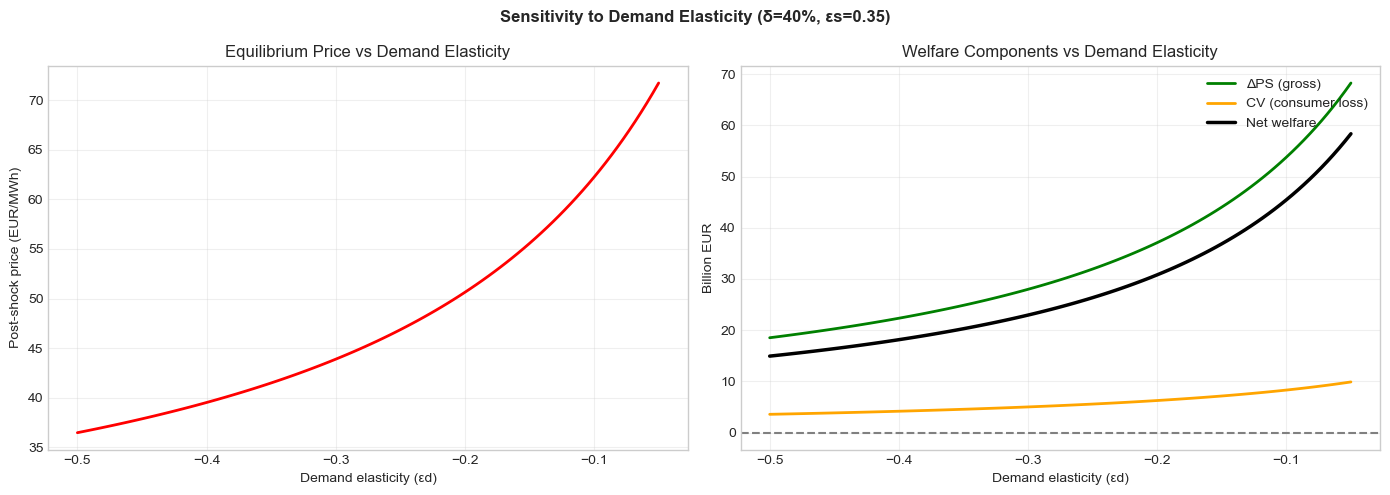

In [21]:
# Sensitivity: demand elasticity
eps_d_range = np.linspace(-0.05, -0.50, 100)
results_d = np.zeros((100, 6))

for i in range(100):
    results_d[i] = compute_welfare(delta, eps_d_range[i], eps_s, tau, norway_share,
                                    passthrough, B_consumer, eta_c, n_households,
                                    I_household, P0, Q0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(eps_d_range, results_d[:, 5], '-r', linewidth=2)
ax1.set_xlabel('Demand elasticity (εd)')
ax1.set_ylabel('Post-shock price (EUR/MWh)')
ax1.set_title('Equilibrium Price vs Demand Elasticity')
ax1.grid(True, alpha=0.3)

ax2.plot(eps_d_range, results_d[:, 0], '-g', linewidth=2, label='ΔPS (gross)')
ax2.plot(eps_d_range, results_d[:, 1], '-', color='orange', linewidth=2, label='CV (consumer loss)')
ax2.plot(eps_d_range, results_d[:, 4], '-k', linewidth=2.5, label='Net welfare')
ax2.axhline(y=0, color='gray', linestyle='--')
ax2.set_xlabel('Demand elasticity (εd)')
ax2.set_ylabel('Billion EUR')
ax2.set_title('Welfare Components vs Demand Elasticity')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Sensitivity to Demand Elasticity (δ={delta:.0%}, εs={eps_s})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Sensitivity to Supply Elasticity ($\epsilon_s$)

Higher supply elasticity means Norwegian producers can expand output more in response to higher prices, but it also means the market supply response dampens the price increase.

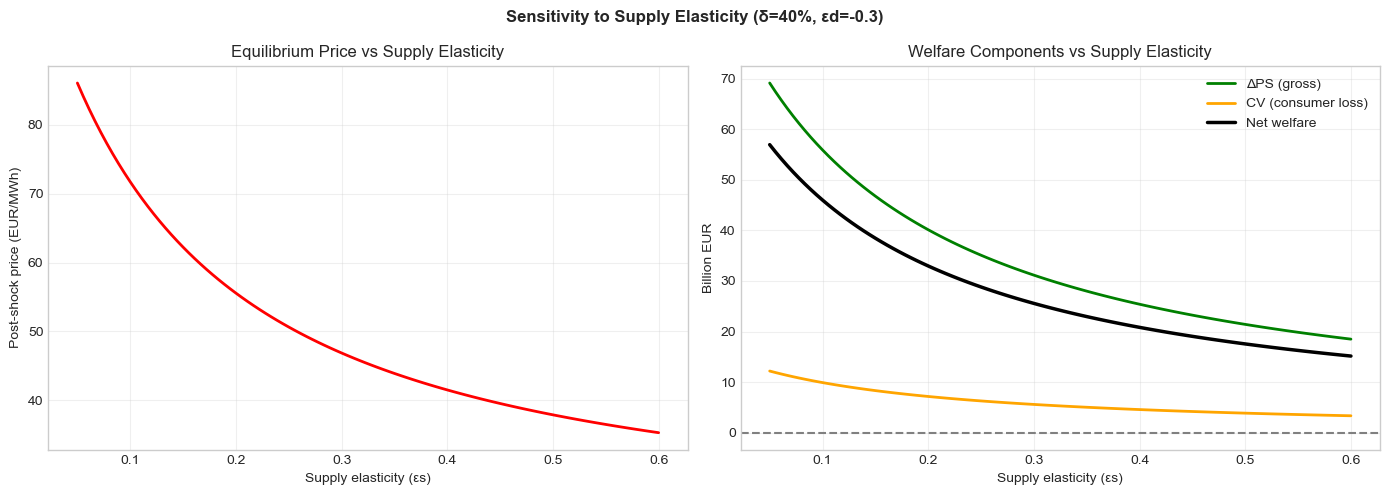

In [22]:
# Sensitivity: supply elasticity
eps_s_range = np.linspace(0.05, 0.60, 100)
results_s = np.zeros((100, 6))

for i in range(100):
    results_s[i] = compute_welfare(delta, eps_d, eps_s_range[i], tau, norway_share,
                                    passthrough, B_consumer, eta_c, n_households,
                                    I_household, P0, Q0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(eps_s_range, results_s[:, 5], '-r', linewidth=2)
ax1.set_xlabel('Supply elasticity (εs)')
ax1.set_ylabel('Post-shock price (EUR/MWh)')
ax1.set_title('Equilibrium Price vs Supply Elasticity')
ax1.grid(True, alpha=0.3)

ax2.plot(eps_s_range, results_s[:, 0], '-g', linewidth=2, label='ΔPS (gross)')
ax2.plot(eps_s_range, results_s[:, 1], '-', color='orange', linewidth=2, label='CV (consumer loss)')
ax2.plot(eps_s_range, results_s[:, 4], '-k', linewidth=2.5, label='Net welfare')
ax2.axhline(y=0, color='gray', linestyle='--')
ax2.set_xlabel('Supply elasticity (εs)')
ax2.set_ylabel('Billion EUR')
ax2.set_title('Welfare Components vs Supply Elasticity')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Sensitivity to Supply Elasticity (δ={delta:.0%}, εd={eps_d})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Sensitivity to Shock Magnitude ($\delta$)

Larger shocks (more Russian gas removed) lead to higher prices, larger PS gains, and larger consumer losses. The net effect depends on the balance.

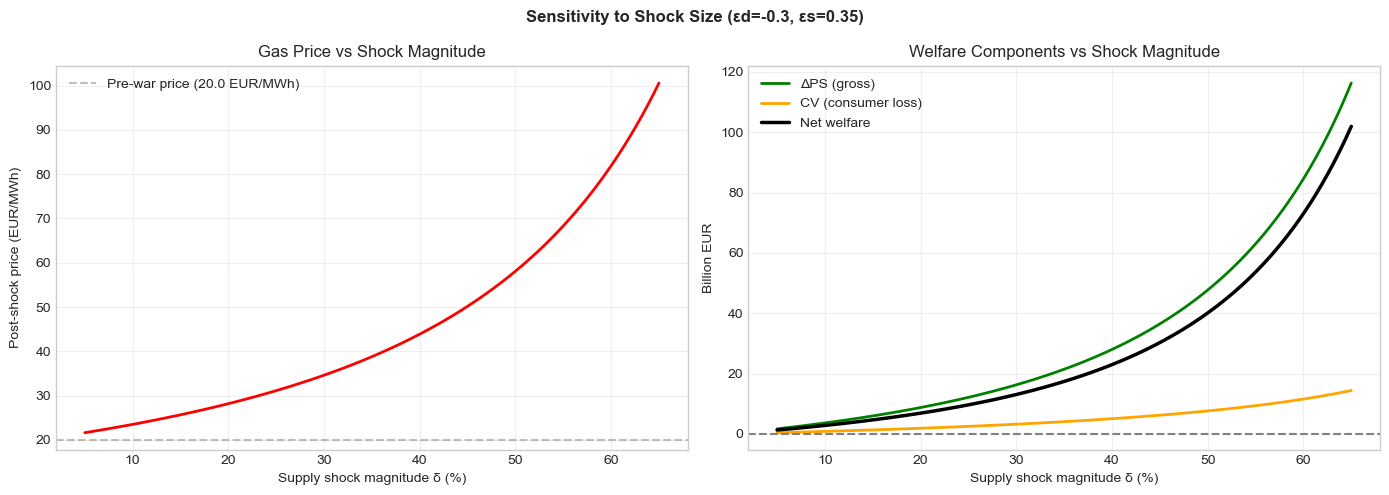

In [23]:
# Sensitivity: shock magnitude
delta_range = np.linspace(0.05, 0.65, 100)
results_delta = np.zeros((100, 6))

for i in range(100):
    results_delta[i] = compute_welfare(delta_range[i], eps_d, eps_s, tau, norway_share,
                                        passthrough, B_consumer, eta_c, n_households,
                                        I_household, P0, Q0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(delta_range * 100, results_delta[:, 5], '-r', linewidth=2)
ax1.axhline(y=P0, linestyle='--', color='gray', alpha=0.5, label=f'Pre-war price ({P0} EUR/MWh)')
ax1.set_xlabel('Supply shock magnitude δ (%)')
ax1.set_ylabel('Post-shock price (EUR/MWh)')
ax1.set_title('Gas Price vs Shock Magnitude')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(delta_range * 100, results_delta[:, 0], '-g', linewidth=2, label='ΔPS (gross)')
ax2.plot(delta_range * 100, results_delta[:, 1], '-', color='orange', linewidth=2, label='CV (consumer loss)')
ax2.plot(delta_range * 100, results_delta[:, 4], '-k', linewidth=2.5, label='Net welfare')
ax2.axhline(y=0, color='gray', linestyle='--')
ax2.set_xlabel('Supply shock magnitude δ (%)')
ax2.set_ylabel('Billion EUR')
ax2.set_title('Welfare Components vs Shock Magnitude')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Sensitivity to Shock Size (εd={eps_d}, εs={eps_s})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Two-Dimensional Robustness: Demand Elasticity vs Shock Magnitude

The heatmap below shows net Norwegian welfare across a grid of demand elasticity and shock magnitude values. The **black contour** marks the zero-welfare boundary — above/left of this line, Norway is a net loser; below/right, Norway is a net winner.

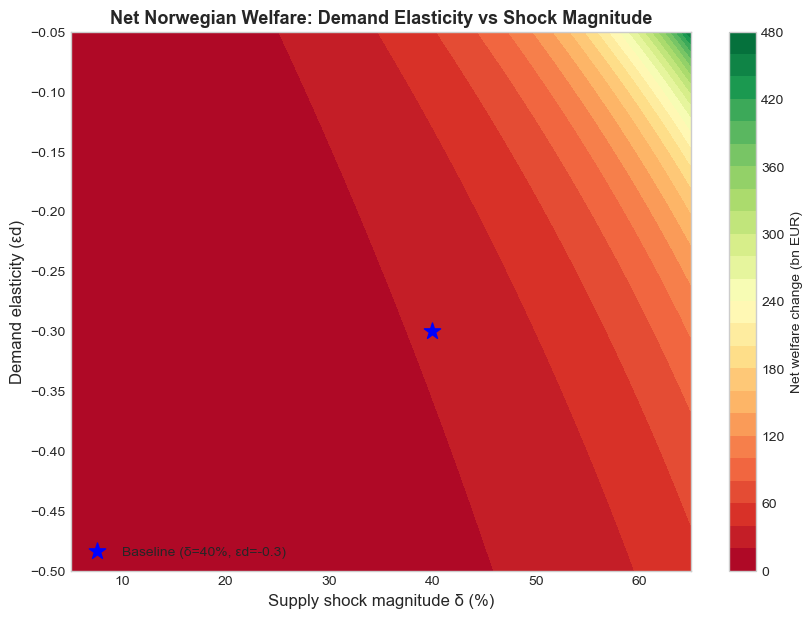

Norway is a net winner in 100% of the parameter space shown.


In [24]:
# 2D heatmap: demand elasticity vs shock magnitude
n_grid = 60
eps_d_grid = np.linspace(-0.05, -0.50, n_grid)
delta_grid = np.linspace(0.05, 0.65, n_grid)
welfare_heat = np.zeros((n_grid, n_grid))

for i in range(n_grid):
    for j in range(n_grid):
        res = compute_welfare(delta_grid[j], eps_d_grid[i], eps_s, tau, norway_share,
                              passthrough, B_consumer, eta_c, n_households, I_household, P0, Q0)
        welfare_heat[i, j] = res[4]  # net welfare in bn EUR

plt.figure(figsize=(10, 7))
cf = plt.contourf(delta_grid * 100, eps_d_grid, welfare_heat, levels=25, cmap='RdYlGn')
plt.colorbar(cf, label='Net welfare change (bn EUR)')
# Zero-welfare contour
cs = plt.contour(delta_grid * 100, eps_d_grid, welfare_heat, levels=[0], colors='black', linewidths=2.5)
plt.clabel(cs, fmt='ΔW=0', fontsize=10)
# Mark baseline
plt.scatter([delta * 100], [eps_d], s=150, color='blue', marker='*', zorder=5, label=f'Baseline (δ={delta:.0%}, εd={eps_d})')
plt.xlabel('Supply shock magnitude δ (%)', fontsize=12)
plt.ylabel('Demand elasticity (εd)', fontsize=12)
plt.title('Net Norwegian Welfare: Demand Elasticity vs Shock Magnitude', fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.2)
plt.show()

# Report the fraction of parameter space where Norway wins
frac_winner = np.mean(welfare_heat > 0) * 100
print(f"Norway is a net winner in {frac_winner:.0f}% of the parameter space shown.")

### 6.5 Who Gains Most? Distributional Sensitivity

The question is not just whether Norway wins, but **how the gains are distributed** across agents as conditions change. The stacked area chart below shows the absolute welfare change for each agent across shock magnitudes.

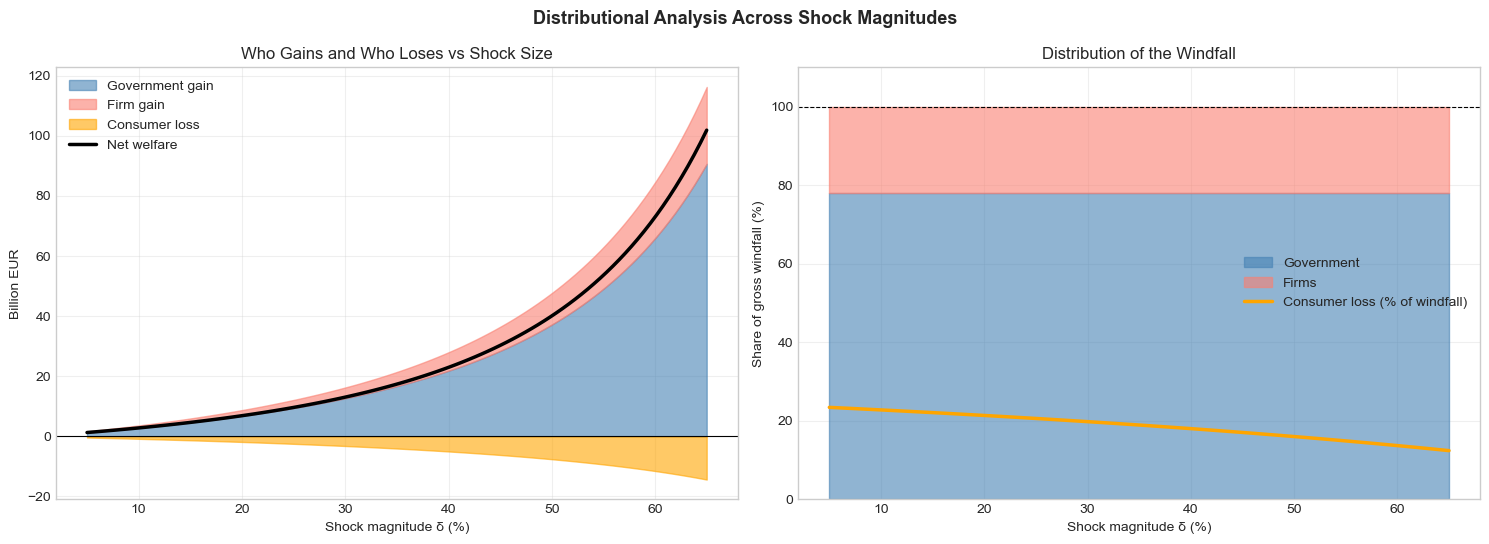

At baseline shock (δ=40%):
  Government captures 78% of the windfall (constant by design)
  Firms retain 22% of the windfall
  Consumer loss offsets 18.0% of the windfall


In [25]:
# Stacked area: WHO GAINS as shock magnitude varies
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: stacked area of all three agents
ax1.fill_between(delta_range * 100, 0, results_delta[:, 2],
                 alpha=0.6, color='steelblue', label='Government gain')
ax1.fill_between(delta_range * 100, results_delta[:, 2],
                 results_delta[:, 2] + results_delta[:, 3],
                 alpha=0.6, color='salmon', label='Firm gain')
ax1.fill_between(delta_range * 100, 0, -results_delta[:, 1],
                 alpha=0.6, color='orange', label='Consumer loss')
ax1.plot(delta_range * 100, results_delta[:, 4], '-k', linewidth=2.5, label='Net welfare')
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.set_xlabel('Shock magnitude δ (%)')
ax1.set_ylabel('Billion EUR')
ax1.set_title('Who Gains and Who Loses vs Shock Size')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Right: government share of TOTAL windfall vs shock magnitude
gov_share = results_delta[:, 2] / results_delta[:, 0] * 100  # gov as % of gross PS
firm_share = results_delta[:, 3] / results_delta[:, 0] * 100
consumer_offset = results_delta[:, 1] / results_delta[:, 0] * 100  # consumer loss as % of gross PS

ax2.fill_between(delta_range * 100, 0, gov_share, alpha=0.6, color='steelblue', label='Government')
ax2.fill_between(delta_range * 100, gov_share, gov_share + firm_share, alpha=0.6, color='salmon', label='Firms')
ax2.axhline(y=100, color='black', linewidth=0.8, linestyle='--')
ax2.plot(delta_range * 100, consumer_offset, '-', color='orange', linewidth=2.5, label='Consumer loss (% of windfall)')
ax2.set_xlabel('Shock magnitude δ (%)')
ax2.set_ylabel('Share of gross windfall (%)')
ax2.set_title('Distribution of the Windfall')
ax2.legend(loc='center right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 110)

plt.suptitle('Distributional Analysis Across Shock Magnitudes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"At baseline shock (δ={delta:.0%}):")
print(f"  Government captures {tau*100:.0f}% of the windfall (constant by design)")
print(f"  Firms retain {(1-tau)*100:.0f}% of the windfall")
print(f"  Consumer loss offsets {CV_total/1e9/(delta_PS/scale)*100:.1f}% of the windfall")

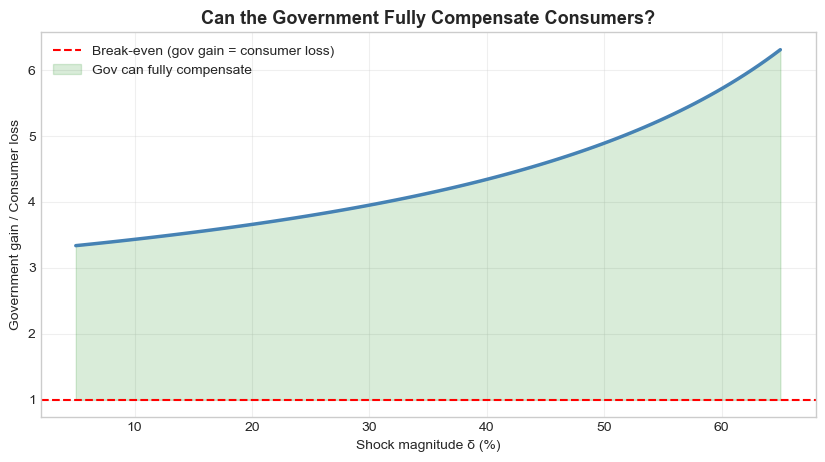

At baseline: government gains 21.83 bn, consumers lose 5.03 bn
Ratio: 4.3x — government could compensate consumers 4.3 times over


In [26]:
# How does the government's ABILITY to compensate consumers change?
# Ratio: government gain / consumer loss
compensation_ratio = results_delta[:, 2] / results_delta[:, 1]

plt.figure(figsize=(10, 5))
plt.plot(delta_range * 100, compensation_ratio, '-', color='steelblue', linewidth=2.5)
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Break-even (gov gain = consumer loss)')
plt.fill_between(delta_range * 100, compensation_ratio, 1,
                 where=(compensation_ratio > 1), alpha=0.15, color='green', label='Gov can fully compensate')
plt.xlabel('Shock magnitude δ (%)')
plt.ylabel('Government gain / Consumer loss')
plt.title('Can the Government Fully Compensate Consumers?', fontsize=13, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print(f"At baseline: government gains {delta_G/scale:.2f} bn, consumers lose {CV_total/1e9:.2f} bn")
print(f"Ratio: {(delta_G/scale)/(CV_total/1e9):.1f}x — government could compensate consumers {(delta_G/scale)/(CV_total/1e9):.1f} times over")

**Key findings from sensitivity analysis:**

1. **The government is always the dominant winner.** The 78% petroleum tax rate is constant, so the government always captures the lion's share of any windfall — regardless of shock size or elasticity parameters.

2. **Consumers always lose, but their loss is small relative to the windfall.** Consumer losses are typically 15–25% of the gross producer surplus gain, meaning the windfall more than covers compensation.

3. **The government can always fully compensate consumers** and still retain a large surplus. The compensation ratio (government gain / consumer loss) is consistently well above 1 — meaning a Pareto improvement is always feasible.

4. **Gas firms gain modestly** — they keep only 22% of the windfall, but this is still a large absolute amount.

5. **The result is robust**: Norway is a net winner across the full range of plausible demand elasticities, supply elasticities, and shock magnitudes.

## 7. Conclusion

### Summary of Findings

This project analysed the welfare effects of the Ukraine war gas supply shock on Norway, decomposing the impact across three agents: gas-producing firms, the Norwegian state, and Norwegian consumers.

In [27]:
# Final summary table
print(f"╔═══════════════════════════════════════════════════════════╗")
print(f"║            SUMMARY OF WELFARE EFFECTS                     ║")
print(f"╠═══════════════════════════════════════════════════════════╣")
print(f"║  Agent                      Effect       Magnitude       ║")
print(f"║  ───────────────────────────────────────────────────────  ║")
print(f"║  Gas firms (after 78% tax)  PS gain     {profit_change_bn:>+8.2f} bn EUR  ║")
print(f"║  Norwegian state            Tax revenue {G_change_bn:>+8.2f} bn EUR  ║")
print(f"║  Norwegian consumers        Welfare loss{-CV_total_bn:>+8.3f} bn EUR  ║")
print(f"║  ───────────────────────────────────────────────────────  ║")
print(f"║  NET WELFARE CHANGE                     {net_W_bn:>+8.2f} bn EUR  ║")
print(f"║  Norway is a net {'WINNER' if net_W_bn > 0 else 'LOSER'}                                   ║")
print(f"╚═══════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════╗
║            SUMMARY OF WELFARE EFFECTS                     ║
╠═══════════════════════════════════════════════════════════╣
║  Agent                      Effect       Magnitude       ║
║  ───────────────────────────────────────────────────────  ║
║  Gas firms (after 78% tax)  PS gain        +6.16 bn EUR  ║
║  Norwegian state            Tax revenue   +21.83 bn EUR  ║
║  Norwegian consumers        Welfare loss  -5.029 bn EUR  ║
║  ───────────────────────────────────────────────────────  ║
║  NET WELFARE CHANGE                       +22.96 bn EUR  ║
║  Norway is a net WINNER                                   ║
╚═══════════════════════════════════════════════════════════╝


**Norway is unambiguously a net winner** from the gas price surge under our baseline parameters, and this result is robust across a wide range of demand elasticities, supply elasticities, and shock magnitudes.

The key mechanism is simple: Norway is a large net exporter of gas. When prices rise, export revenue gains far exceed the domestic consumer welfare loss — especially because the petroleum tax system channels 78% of the windfall to the government, which in principle can redistribute it.

### The Role of the Tax System

The Norwegian petroleum tax is approximately optimal from a Ramsey perspective. Because it taxes *economic rents* (profits) rather than production per unit, it creates **zero deadweight loss**. This means the state can extract nearly the entire windfall without distorting production decisions — a textbook example of efficient taxation of natural resource rents.

### Limitations

- **Partial equilibrium**: We ignore general equilibrium effects such as exchange rate appreciation ("Dutch disease"), wage pressures, or crowding out of non-petroleum sectors.
- **Constant elasticity**: The constant-elasticity functional form may not hold over such extreme price changes.
- **Simplified passthrough**: The gas-to-electricity price passthrough is modeled as a fixed coefficient. In reality, Norway's large hydropower capacity provides a buffer.
- **Static analysis**: We do not model dynamic adjustment — investment in new capacity, LNG infrastructure, demand response over time, or strategic behaviour.
- **Representative consumer**: We use a single representative household. In reality, the burden falls unevenly across income groups.

### Broader Implications

The analysis illustrates a general principle: countries with well-designed tax systems on natural resources can transform adverse global supply shocks into net domestic welfare gains. The critical ingredients are (1) being a large net exporter and (2) having a tax system that captures rents without distorting production.